<a href="https://colab.research.google.com/github/mazharshakoor55-netizen/eurosat-landcover-cnn/blob/main/eurosat_landcover_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
from torchvision.datasets import EuroSAT
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)


Using: cuda


In [2]:
transform = transforms.ToTensor()   # turn images into tensors for now

full_dataset = EuroSAT(root="data", download=True, transform=transform)

print("Total images:", len(full_dataset))
print("Classes:", full_dataset.classes)


100%|██████████| 94.3M/94.3M [00:01<00:00, 76.7MB/s]


Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


Image shape: torch.Size([3, 64, 64])
Label number: 0
Label name: AnnualCrop


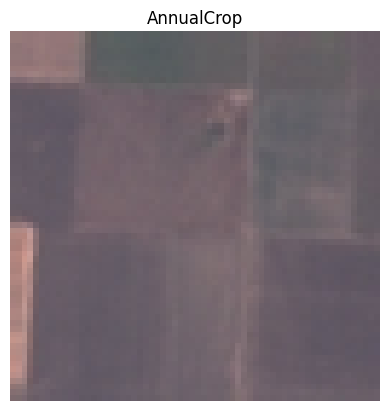

In [3]:
image, label = full_dataset[0]   # first image and its label number

print("Image shape:", image.shape)        # [3, 64, 64] = 3 bands, 64x64
print("Label number:", label)
print("Label name:", full_dataset.classes[label])

# show it (move channels to the end so matplotlib can display it)
plt.imshow(image.permute(1, 2, 0))
plt.title(full_dataset.classes[label])
plt.axis("off")
plt.show()

In [4]:
from collections import Counter

# label number for every image
all_labels = [label for _, label in full_dataset]
counts = Counter(all_labels)

for class_index, n in sorted(counts.items()):
    print(full_dataset.classes[class_index], ":", n)

AnnualCrop : 3000
Forest : 3000
HerbaceousVegetation : 3000
Highway : 2500
Industrial : 2500
Pasture : 2000
PermanentCrop : 2500
Residential : 3000
River : 2500
SeaLake : 3000


In [5]:
# transforms: convert to tensor and normalise pixel values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

dataset = EuroSAT(root="data", download=True, transform=transform)

# split: 70% train, 15% validation, 15% test
n_total = len(dataset)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42))

print(n_train, n_val, n_test)

18900 4050 4050


In [6]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False)

print("Batches per loader:", len(train_loader), len(val_loader), len(test_loader))

Batches per loader: 296 64 64


In [7]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # convolution layers find visual patterns
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)   # shrinks the image by half
        # fully-connected layers make the final decision
        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 64 -> 32
        x = self.pool(F.relu(self.conv2(x)))   # 32 -> 16
        x = x.view(x.size(0), -1)              # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)                        # 10 scores out
        return x

model = SmallCNN().to(device)
print(model)

SmallCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [8]:
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print("Loss and optimiser ready.")

Loss and optimiser ready.


In [10]:
def evaluate(loader):
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = outputs.argmax(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

EPOCHS = 8
for epoch in range(EPOCHS):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    val_acc = evaluate(val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}  loss {loss.item():.3f}  val_acc {val_acc:.1f}%")

Epoch 1/8  loss 1.204  val_acc 70.3%
Epoch 2/8  loss 0.375  val_acc 76.4%
Epoch 3/8  loss 0.688  val_acc 78.2%
Epoch 4/8  loss 0.533  val_acc 79.6%
Epoch 5/8  loss 0.184  val_acc 83.7%
Epoch 6/8  loss 0.148  val_acc 81.9%
Epoch 7/8  loss 0.152  val_acc 83.4%
Epoch 8/8  loss 0.636  val_acc 84.0%


In [11]:
test_acc = evaluate(test_loader)
print(f"FINAL TEST ACCURACY: {test_acc:.1f}%")

FINAL TEST ACCURACY: 83.9%


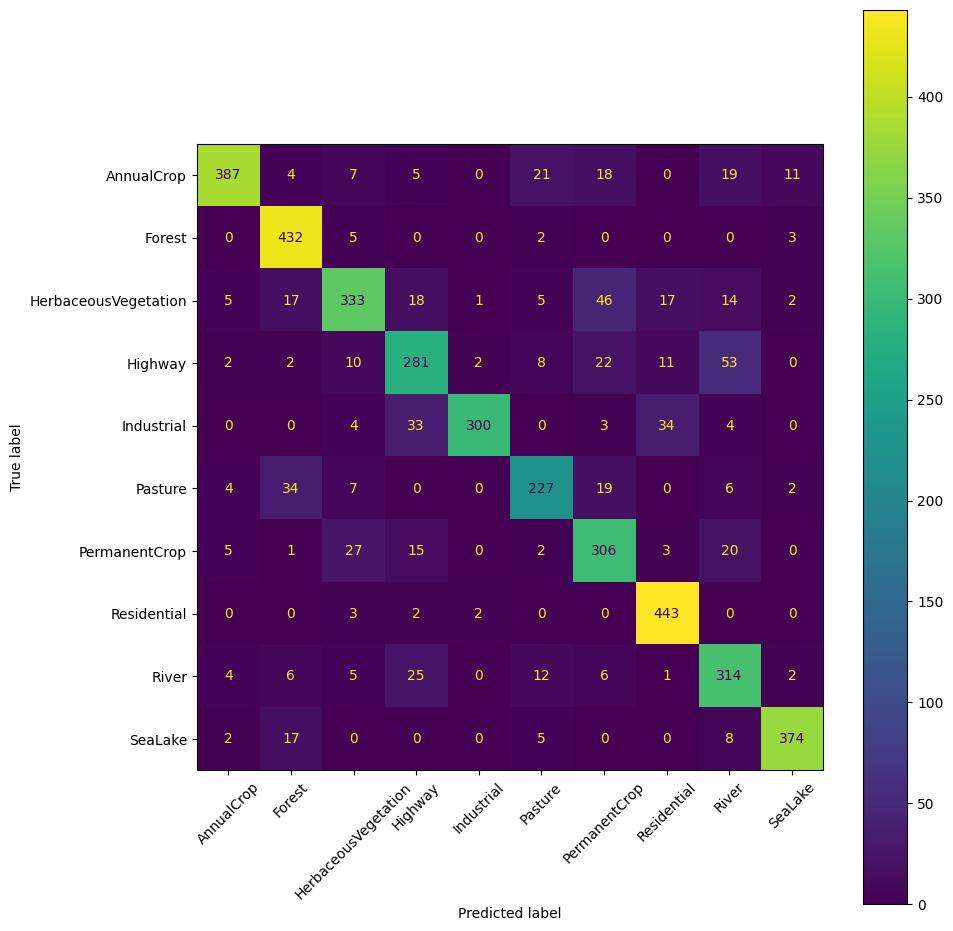

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []; all_true = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_true.extend(labels.tolist())

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=dataset.classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)   # save for GitHub
plt.show()

In [13]:
from torchvision import models

# load ResNet-18 with pretrained weights
resnet = models.resnet18(weights="IMAGENET1K_V1")

# replace its final layer to output 10 classes (not 1000)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)
resnet = resnet.to(device)

optimizer = torch.optim.Adam(resnet.parameters(), lr=0.0003)
print("ResNet-18 ready.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 90.0MB/s]


ResNet-18 ready.


In [14]:
EPOCHS = 8
for epoch in range(EPOCHS):
    resnet.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet(images)           # 1. forward
        loss = loss_fn(outputs, labels)    # 2. loss
        optimizer.zero_grad()
        loss.backward()                    # 3. backward
        optimizer.step()                   # 4. update

    # evaluate() uses 'model' inside it — so we point it at resnet too
    resnet.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            predicted = outputs.argmax(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS}  loss {loss.item():.3f}  val_acc {val_acc:.1f}%")

Epoch 1/8  loss 0.674  val_acc 94.0%
Epoch 2/8  loss 0.394  val_acc 95.1%
Epoch 3/8  loss 0.017  val_acc 93.8%
Epoch 4/8  loss 0.002  val_acc 96.1%
Epoch 5/8  loss 0.014  val_acc 95.4%
Epoch 6/8  loss 0.002  val_acc 95.6%
Epoch 7/8  loss 0.380  val_acc 96.4%
Epoch 8/8  loss 0.513  val_acc 96.7%


In [15]:
resnet.eval()
correct = 0; total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet(images)
        predicted = outputs.argmax(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
test_acc = 100 * correct / total
print(f"RESNET FINAL TEST ACCURACY: {test_acc:.1f}%")

RESNET FINAL TEST ACCURACY: 96.6%


In [16]:
torch.save(resnet.state_dict(), "eurosat_resnet18.pth")
print("Model saved.")

Model saved.
